In [1]:
# ===============================
# 1) Imports + notebook defaults
# ===============================

# Libraries for Data Handling
import numpy as np
import pandas as pd
from pathlib import Path
 
# Libraries for Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for Machine Learning
from sklearn.model_selection import train_test_split



# Global Configuration & Styling

# Set Random Seed for Reproducibility
TEST_SIZE = 0.20
RANDOM_STATE = 42

# Visualization Settings
sns.set_theme(style='whitegrid') 
plt.rcParams['figure.figsize'] = (12, 6) 
plt.rcParams['font.size'] = 12

# Pandas Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) 
pd.set_option('display.float_format', lambda x: '%.3f' % x) 


In [2]:
# ===================================
# 2) Load data + quick sanity checks
# ===================================


# Path to the CSV
DATA_PATH = Path('../Data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Raise an error if file is not found
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH.resolve()}.")

print(f"Loading dataset from: {DATA_PATH}")

# Load raw data
df_raw = pd.read_csv(DATA_PATH)

# Creating a working copy in case i need to restart cleaning later
df = df_raw.copy()
print("Dataset loaded and copy created.")

# Initial Inspection:

# Core columns we rely on throughout the notebook
expected_cols = {'customerID', 'Churn'}

missing_cols = expected_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Dataset is missing expected columns: {missing_cols}")

# Shape Check
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

# Duplicate Check (excluding identifier column)
duplicate_mask = df.duplicated(
    subset=df.columns.difference(['customerID']),
    keep=False
)

n_duplicates = duplicate_mask.sum()

if n_duplicates > 0:
    print(f"Warning: {n_duplicates} duplicate rows detected.")
else:
    print("No duplicate rows detected.")

# Quick schema overview
print("Dataset Information:")
display(df.info())

# Preview first rows
print("First 5 Rows:")
display(df.head())


Loading dataset from: ..\Data\WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset loaded and copy created.
Shape: 7043 rows, 21 columns.
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null 

None

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


,count,percentage
churn,,
No,5174,73.463
Yes,1869,26.537


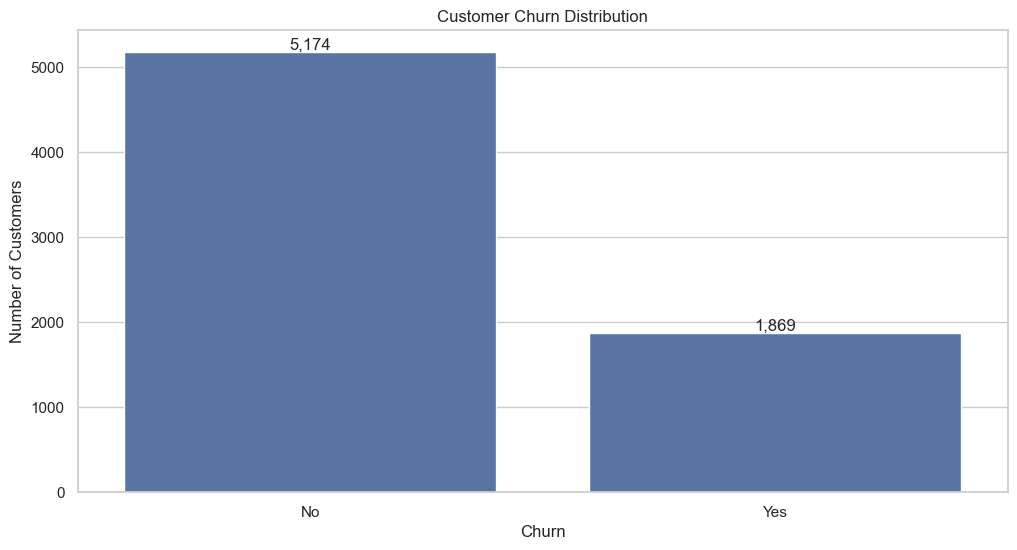

In [3]:
# ===============================
# 3) Target variable exploration
# ===============================


# Inspect target variable distribution
target_col= 'Churn'

# Basic value counts
churn_counts= df[target_col].value_counts()
churn_percentages= df[target_col].value_counts(normalize= True) * 100

churn_summary= pd.DataFrame({
    'count': churn_counts,
    'percentage': churn_percentages                         
}).rename_axis('churn')

display(churn_summary)

# Visualization: Churn distribution
fig, ax = plt.subplots()

sns.barplot(
    x= churn_counts.index,
    y= churn_counts.values,
    ax= ax
)

ax.set_title('Customer Churn Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')

for i, value in enumerate(churn_counts.values):
    ax.text(i, value, f"{value:,}", ha= 'center', va= 'bottom')

plt.show()

In [4]:
# ============================================================
# 4) Feature Overview & Identification (No Transformations)
# ============================================================

target_col = 'Churn'
id_col = 'customerID'

# Candidate feature columns (exclude id + target)
feature_cols = [c for c in df.columns if c not in {id_col, target_col}]
print(f"Number of candidate feature columns: {len(feature_cols)}")

# Split by pandas dtype (initial pass)
numeric_by_dtype = df[feature_cols].select_dtypes(include=['number']).columns.tolist()
categorical_by_dtype = df[feature_cols].select_dtypes(exclude=['number']).columns.tolist()

print(f"Numeric features by dtype: {len(numeric_by_dtype)}")
print(f"Categorical features by dtype: {len(categorical_by_dtype)}")

# Telco dataset:
# - SeniorCitizen is coded as 0/1 but it's a binary column rather than numeric
# - TotalCharges is often loaded as object because of blank strings, treat as numeric later

# Columns that might be categorical in meaning but stored as numeric in this dataset
likely_categorical_meaning = ['SeniorCitizen'] # numeric 0/1 but categorical meaning
likely_categorical_meaning = [c for c in likely_categorical_meaning if c in df.columns]

# Columns that might be numeric in meaning but stored as object in this dataset
likely_numeric_meaning = ['TotalCharges']
likely_numeric_meaning = [c for c in likely_numeric_meaning if c in df.columns]

# Create final numeric/categorical groups in meaning 
numerical_cols = sorted((set(numeric_by_dtype) | set(likely_numeric_meaning)) - set(likely_categorical_meaning))
categorical_cols = sorted((set(categorical_by_dtype) | set(likely_categorical_meaning))- set(likely_numeric_meaning))

# Ensure that there is no overlap
overlap = set(numerical_cols) & set(categorical_cols)
if overlap:
    raise ValueError(f"Numerical and categorical groups overlap: {sorted(overlap)}")

print("\nFinal column groupings (by meaning not dtype):")
print(f"  Numerical:   {len(numerical_cols)}")
print(f"  Categorical: {len(categorical_cols)}")

# Quick summaries without cleaning or changing anything yet

# Quick numeric summary (true numeric dtype only, TotalCharges will be handled after cleaning)
if numeric_by_dtype:
    display(df[numeric_by_dtype].describe())

# Cardinality overview helps decide which categoricals may need special handling later
cat_cardinality = (
    df[categorical_cols]
    .nunique(dropna=False)
    .sort_values(ascending=False)
    .to_frame(name='n_unique_including_nan')
)
display(cat_cardinality)

# Top values for a few categorical columns (kept small to avoid spam)
preview_cols = categorical_cols[:6]
for col in preview_cols:
    print(f"\nTop values for '{col}':")
    display(df[col].value_counts(dropna=False).head(10))
    

Number of candidate feature columns: 19
Numeric features by dtype: 3
Categorical features by dtype: 16

Final column groupings (by meaning not dtype):
  Numerical:   3
  Categorical: 16


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000,7043.000,7043.000
mean,0.162,32.371,64.762
std,0.369,24.559,30.090
min,0.000,0.000,18.250
25%,0.000,9.000,35.500
50%,0.000,29.000,70.350
75%,0.000,55.000,89.850
max,1.000,72.000,118.750


,n_unique_including_nan
PaymentMethod,4
Contract,3
DeviceProtection,3
InternetService,3
MultipleLines,3
OnlineBackup,3
OnlineSecurity,3
StreamingMovies,3
StreamingTV,3
TechSupport,3



Top values for 'Contract':


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

...

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


Top values for 'MultipleLines':


MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


Top values for 'OnlineBackup':


OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

Skipping numeric-in-meaning columns that are not numeric dtype yet (handled in cleaning later):
  TotalCharges
Baseline churn rate (Yes): 26.54%

Numerical features vs Churn (group summaries):


MonthlyCharges                                     tenure         \
                count   mean median    std    min     max  count   mean   
_churn                                                                    
0                5174 61.265 64.425 31.093 18.250 118.750   5174 37.570   
1                1869 74.441 79.650 24.666 18.850 118.350   1869 17.979   

                              
       median    std min max  
_churn                        
0      38.000 24.114   0  72  
1      10.000 19.531   1  72

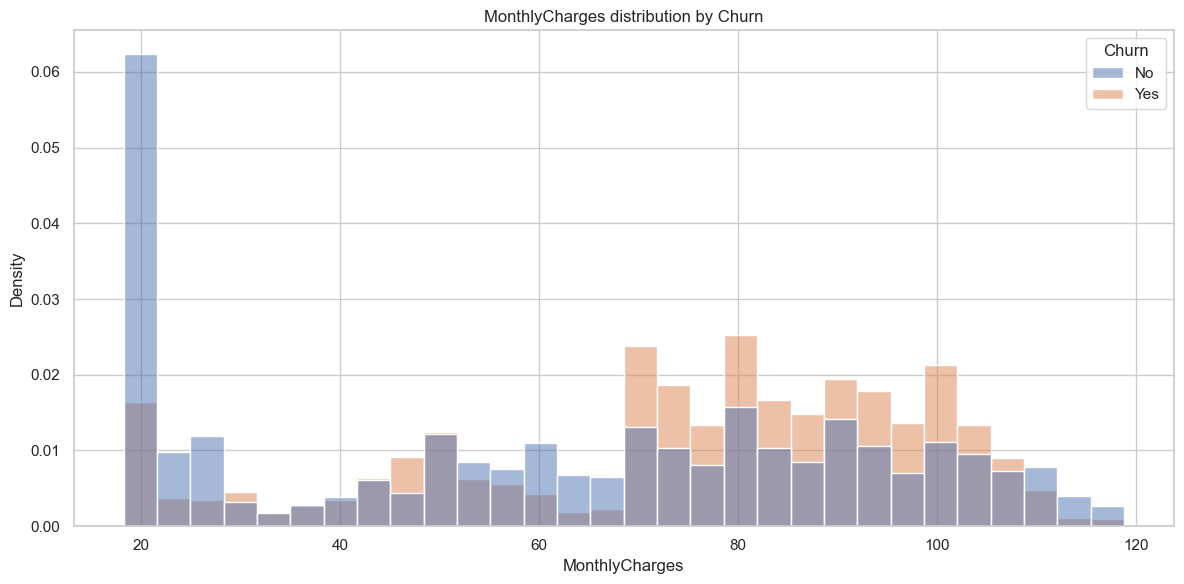

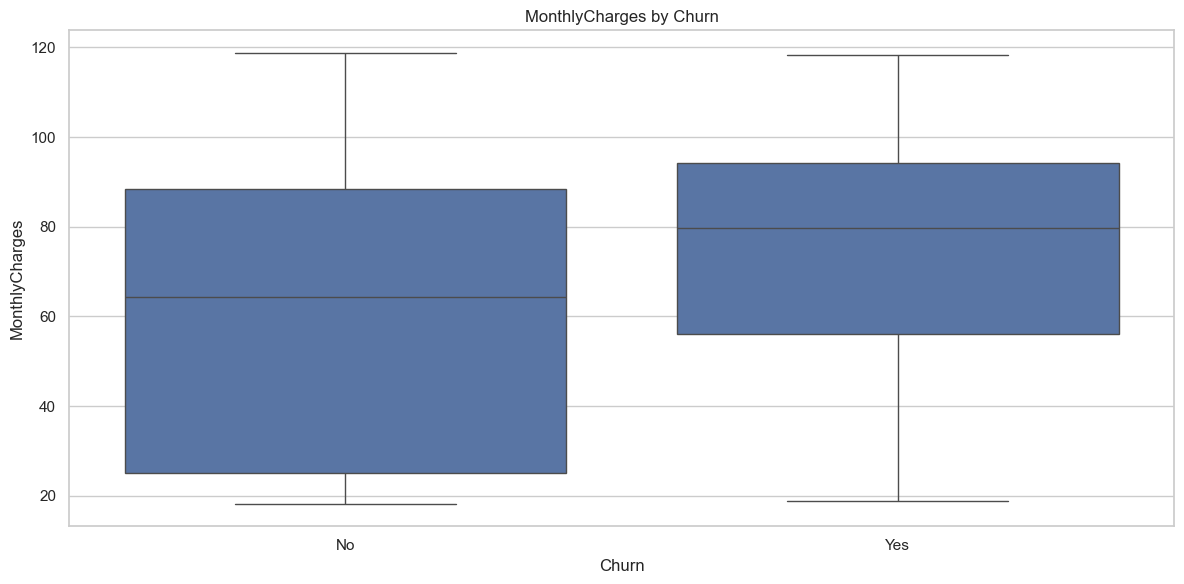

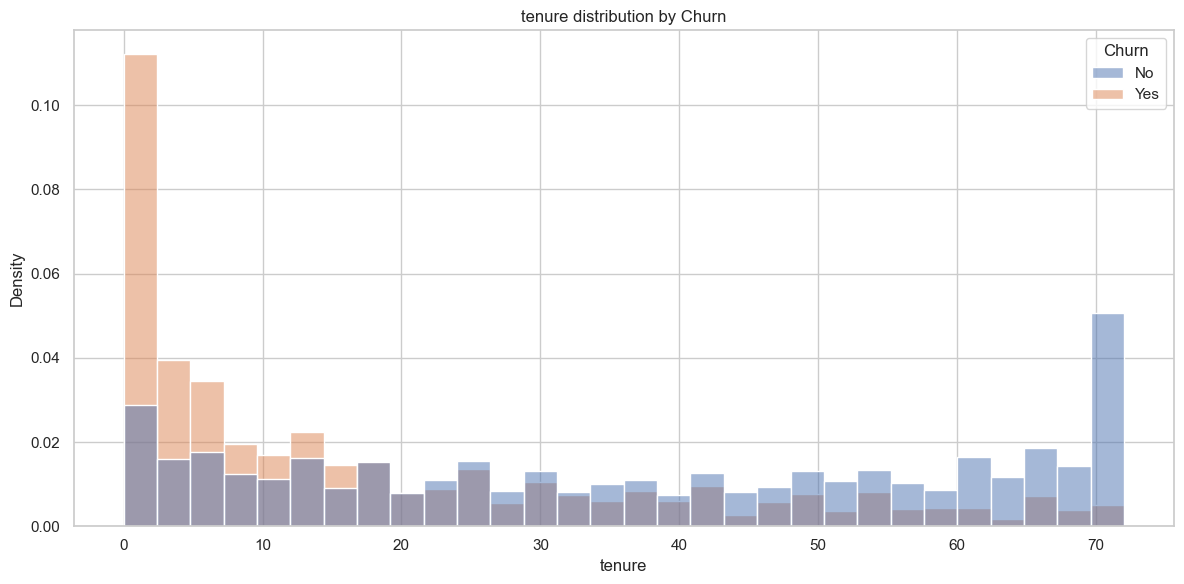

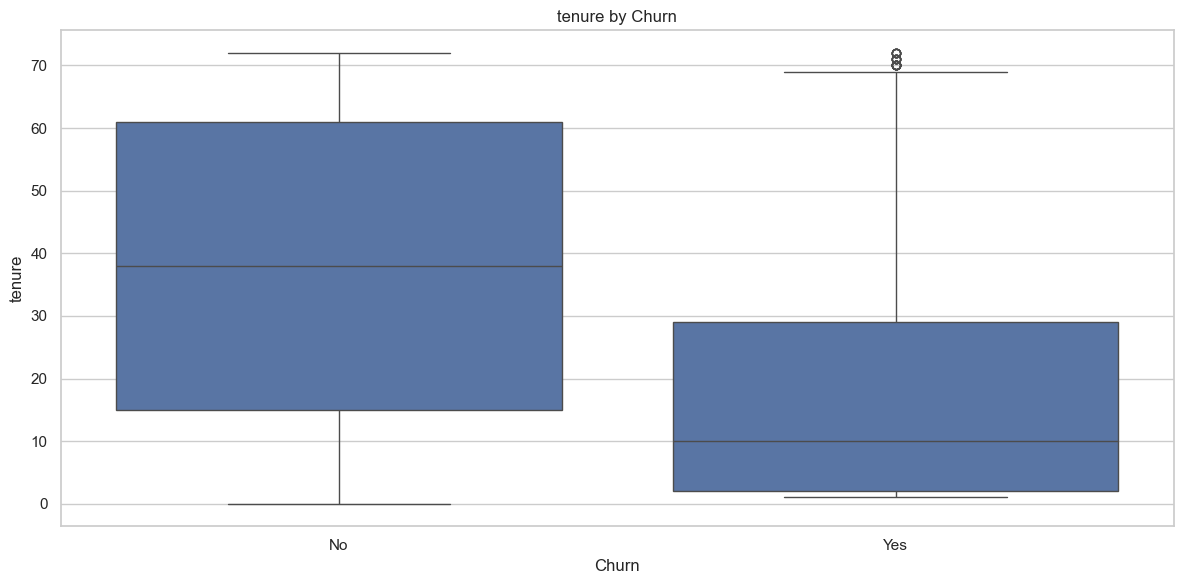


Churn rate by 'Contract':


,n,churn_rate,churned
Contract,,,
Month-to-month,3875,0.427,1655
One year,1473,0.113,166
Two year,1695,0.028,48


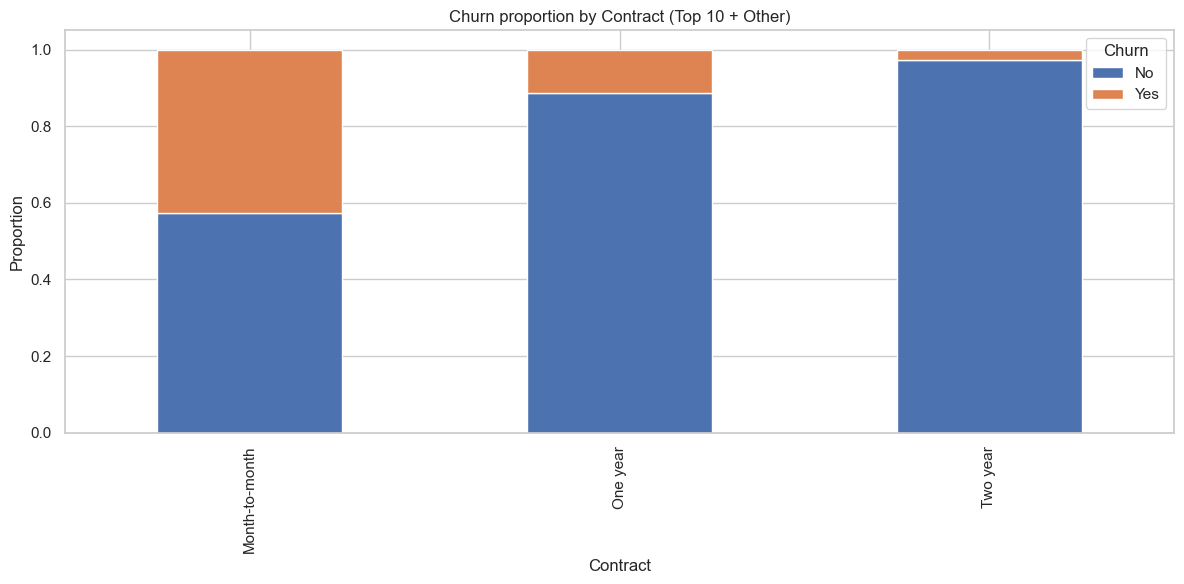

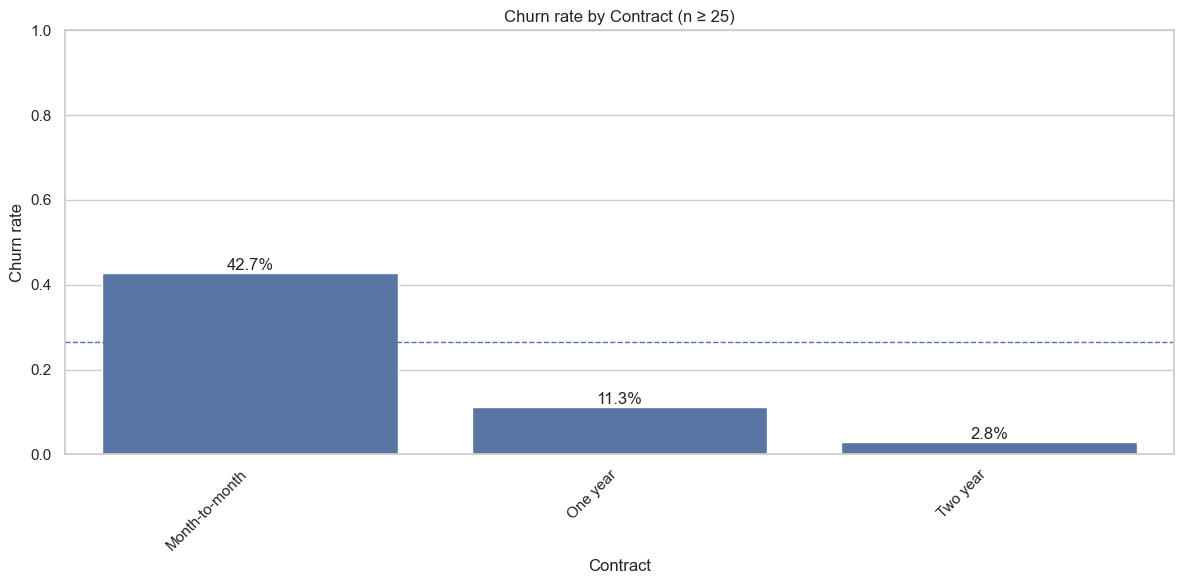


Churn rate by 'Dependents':


,n,churn_rate,churned
Dependents,,,
No,4933,0.313,1543
Yes,2110,0.155,326


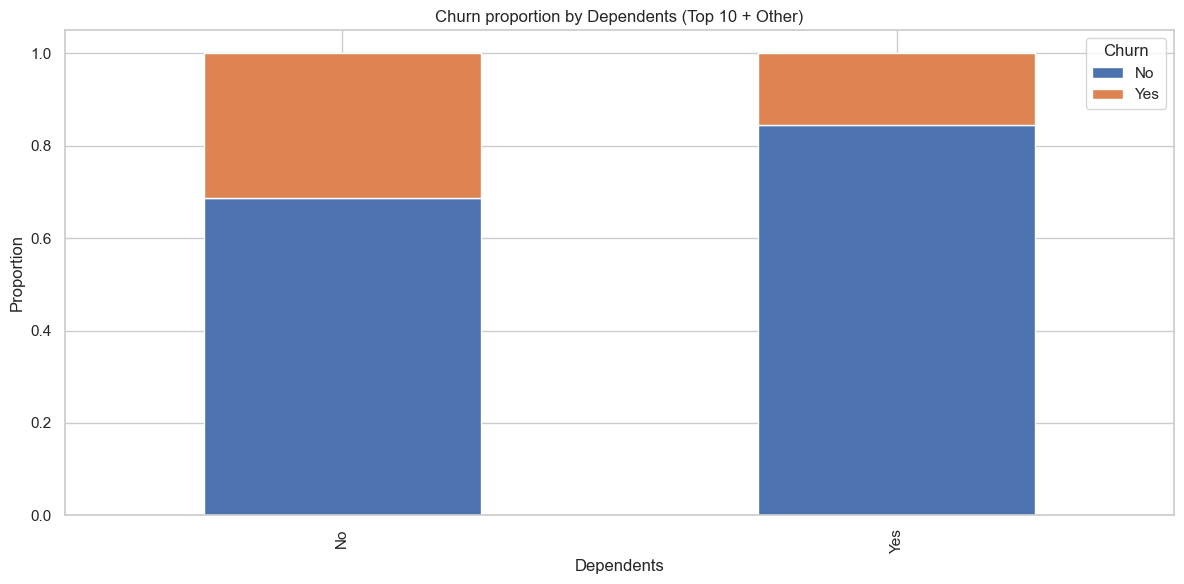

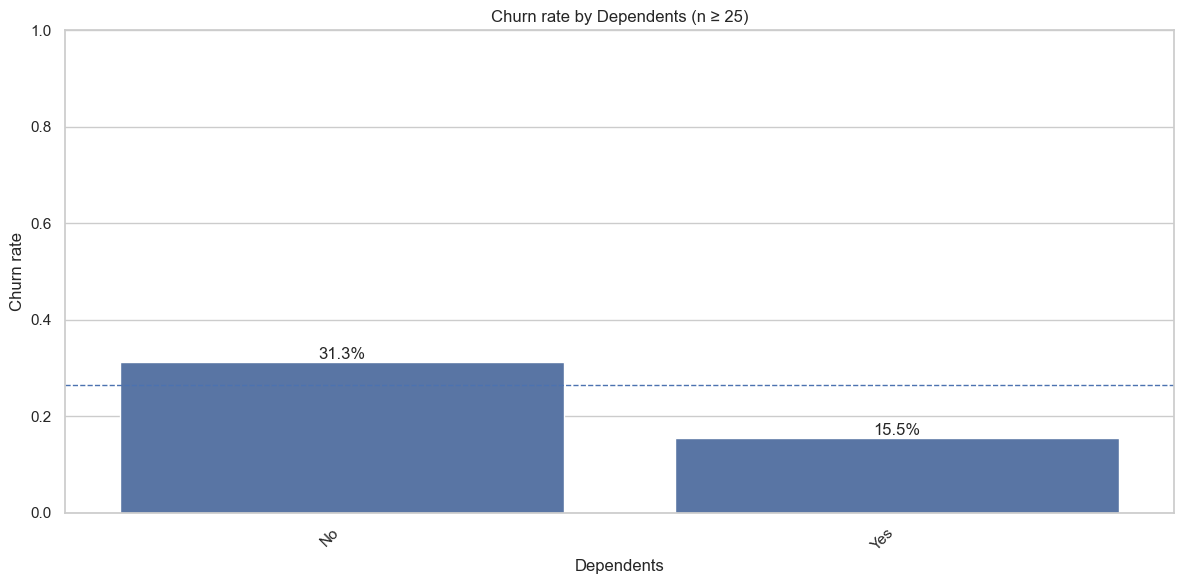


Churn rate by 'DeviceProtection':


,n,churn_rate,churned
DeviceProtection,,,
No,3095,0.391,1211
Yes,2422,0.225,545
No internet service,1526,0.074,113


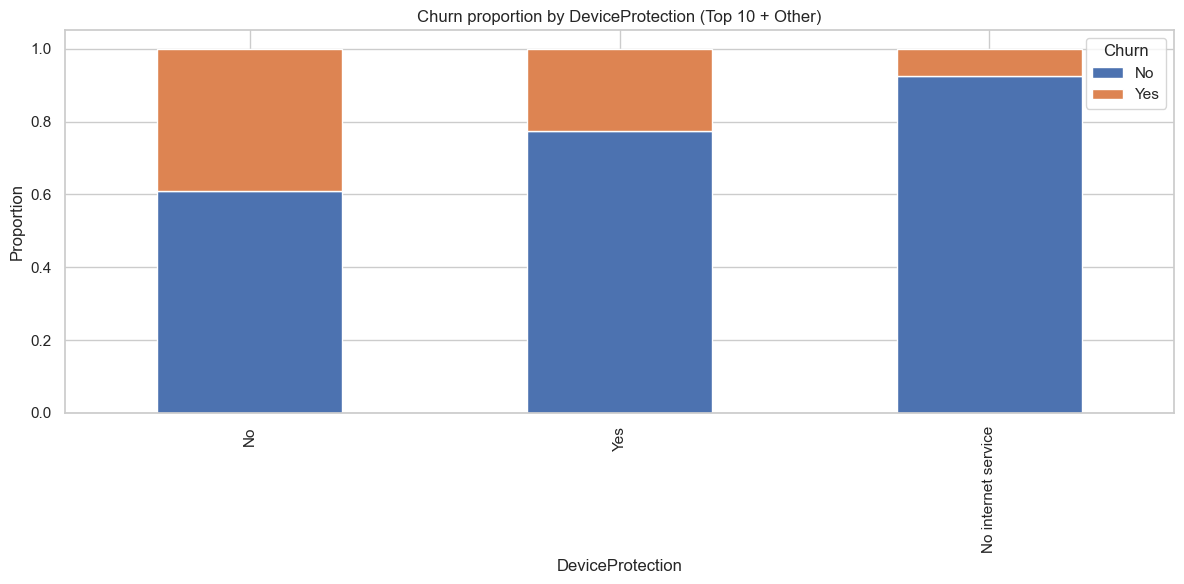

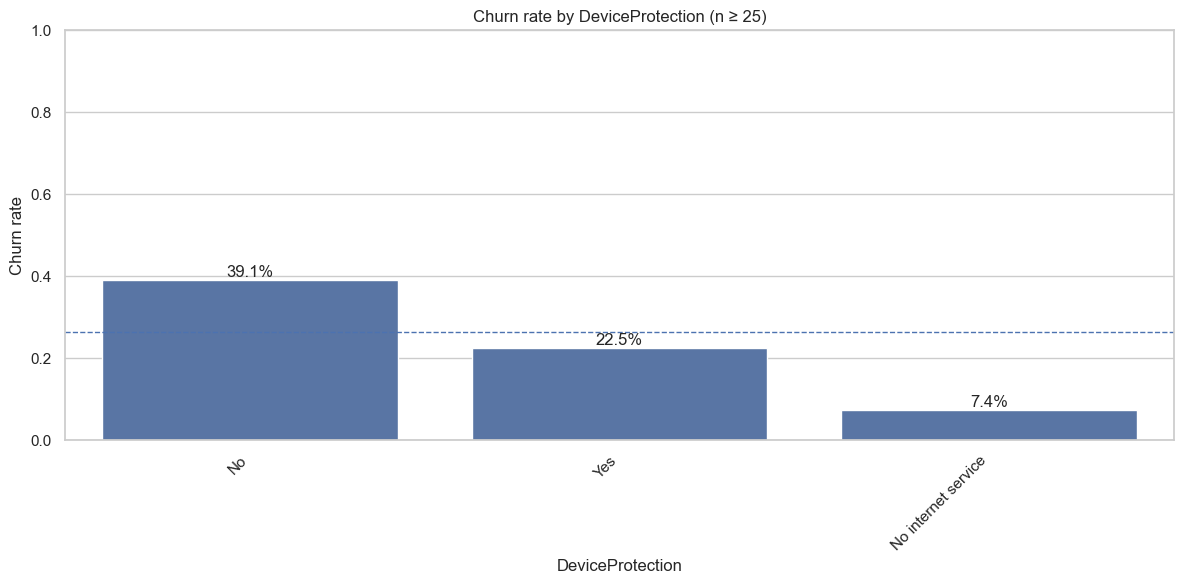


Churn rate by 'InternetService':


,n,churn_rate,churned
InternetService,,,
Fiber optic,3096,0.419,1297
DSL,2421,0.190,459
No,1526,0.074,113


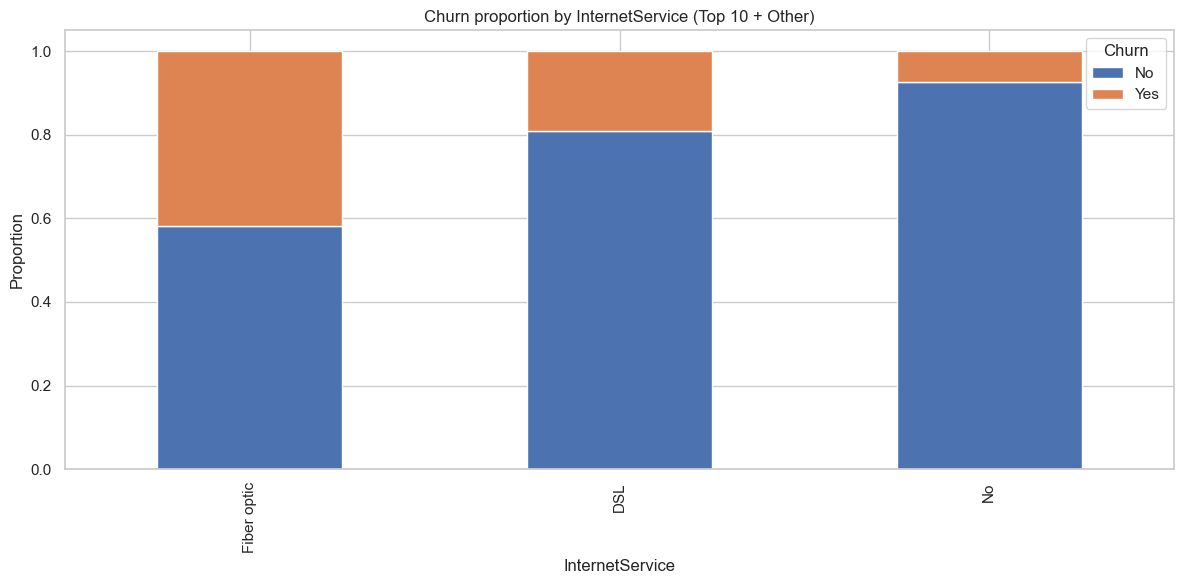

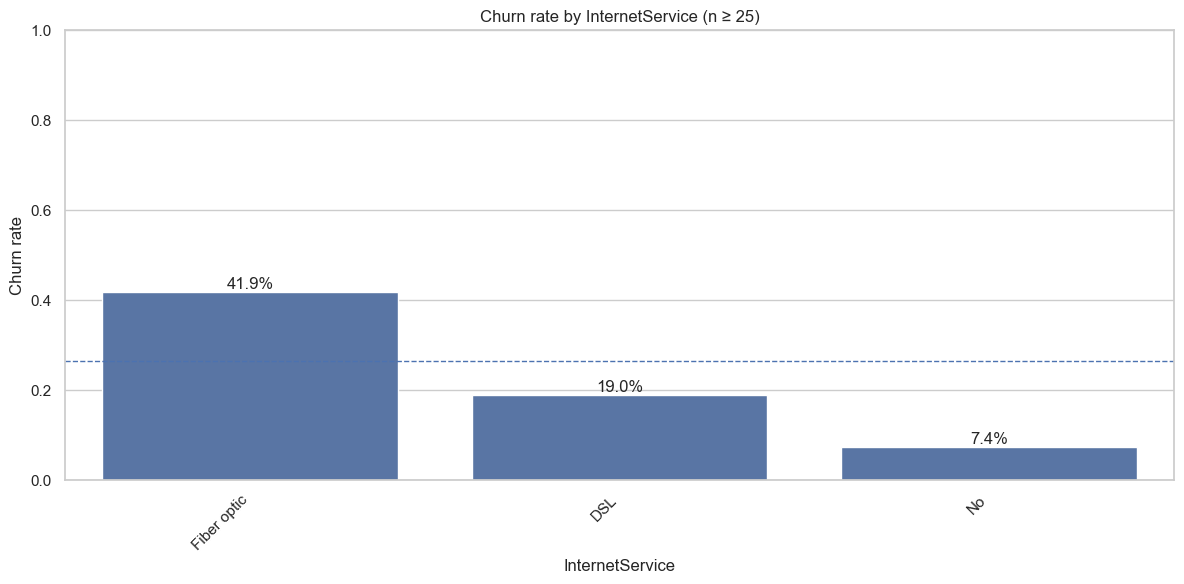


Churn rate by 'MultipleLines':


,n,churn_rate,churned
MultipleLines,,,
Yes,2971,0.286,850
No,3390,0.250,849
No phone service,682,0.249,170


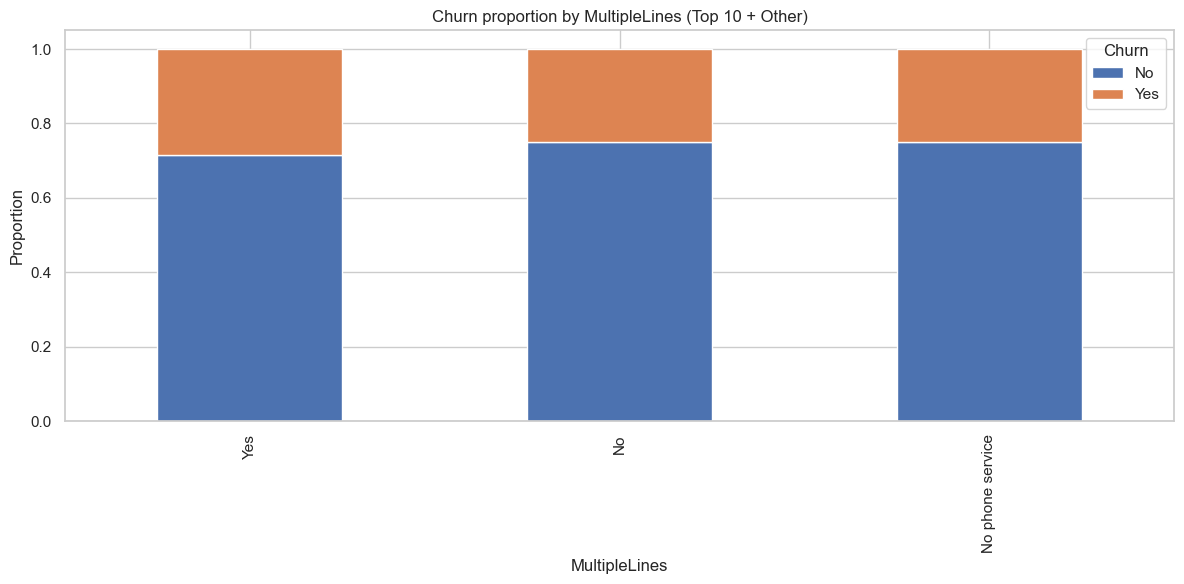

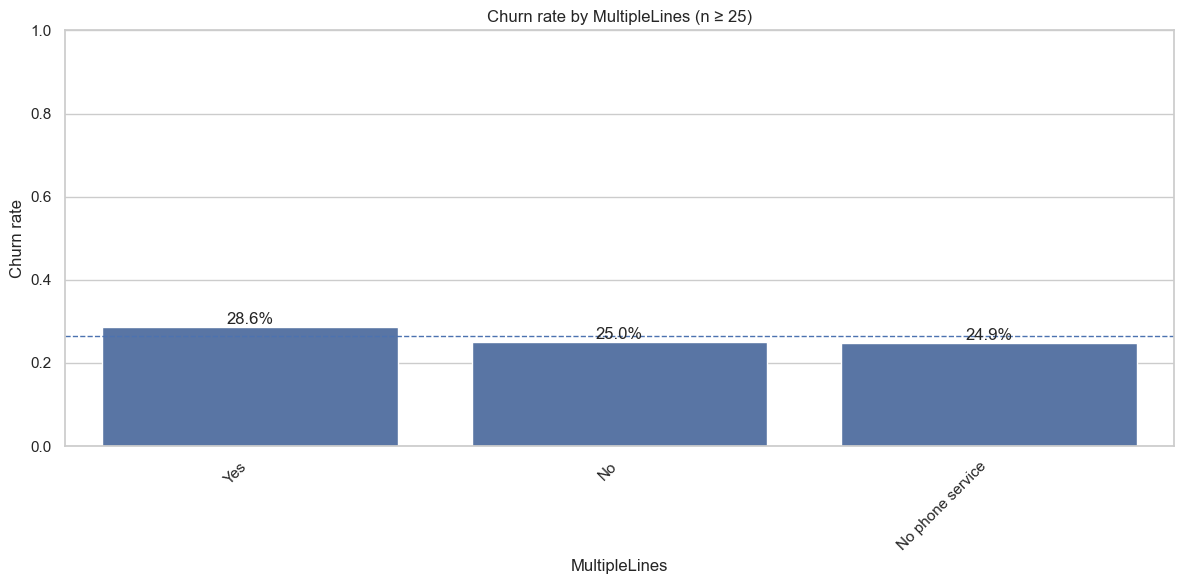


Churn rate by 'OnlineBackup':


,n,churn_rate,churned
OnlineBackup,,,
No,3088,0.399,1233
Yes,2429,0.215,523
No internet service,1526,0.074,113


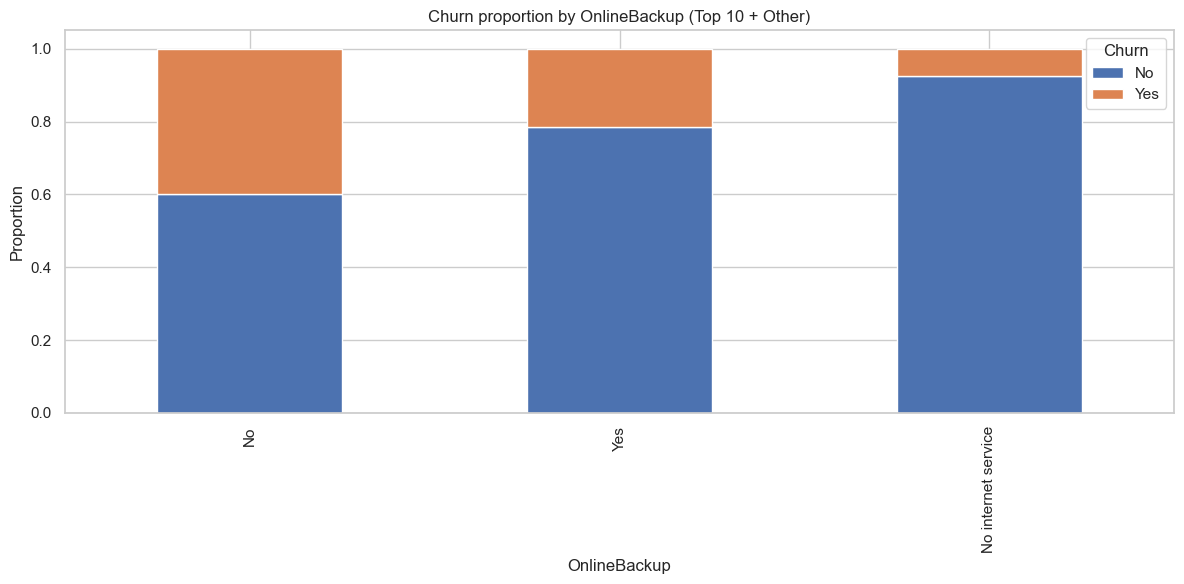

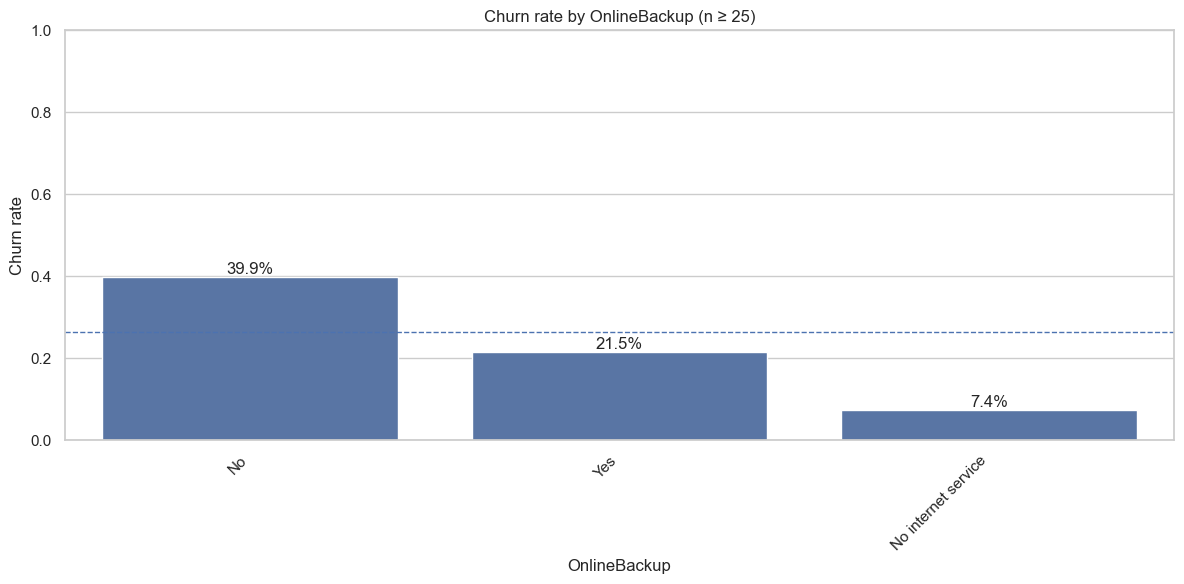


Churn rate by 'OnlineSecurity':


,n,churn_rate,churned
OnlineSecurity,,,
No,3498,0.418,1461
Yes,2019,0.146,295
No internet service,1526,0.074,113


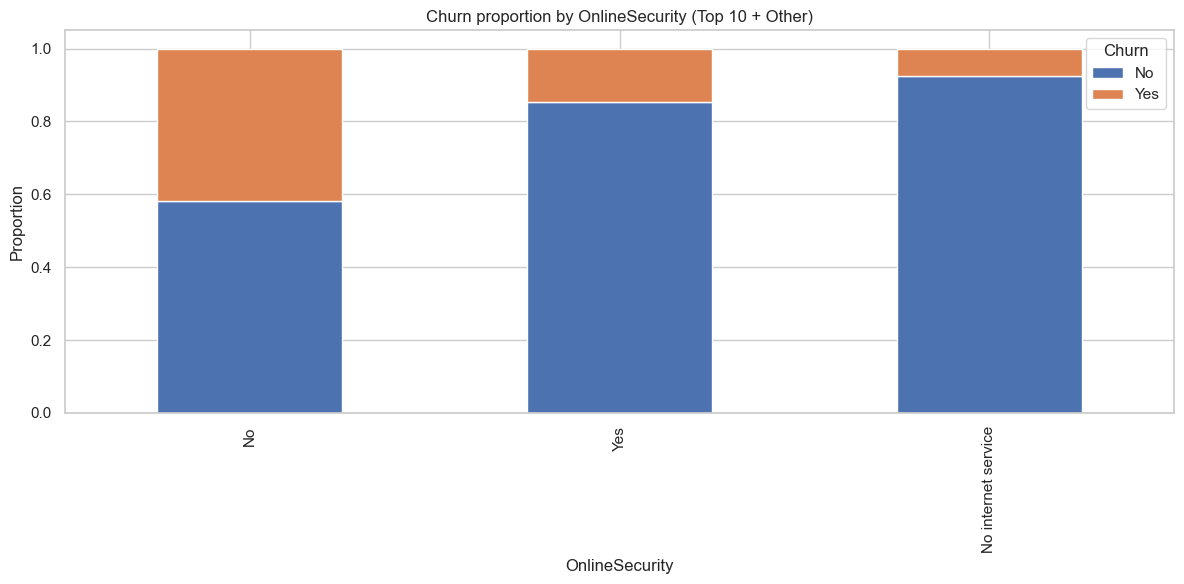

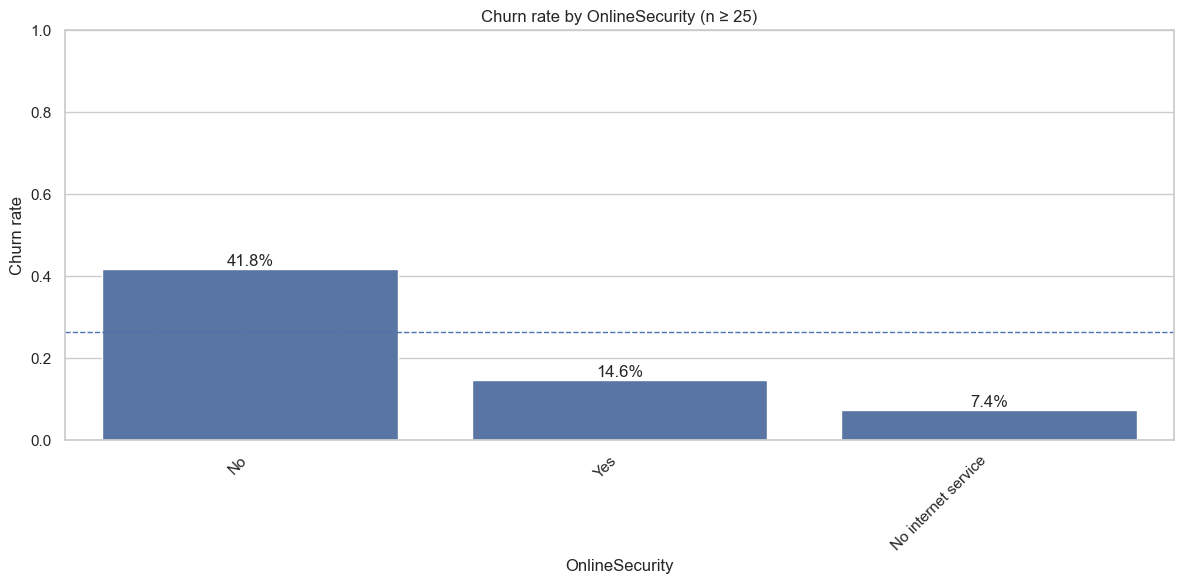


Churn rate by 'PaperlessBilling':


,n,churn_rate,churned
PaperlessBilling,,,
Yes,4171,0.336,1400
No,2872,0.163,469


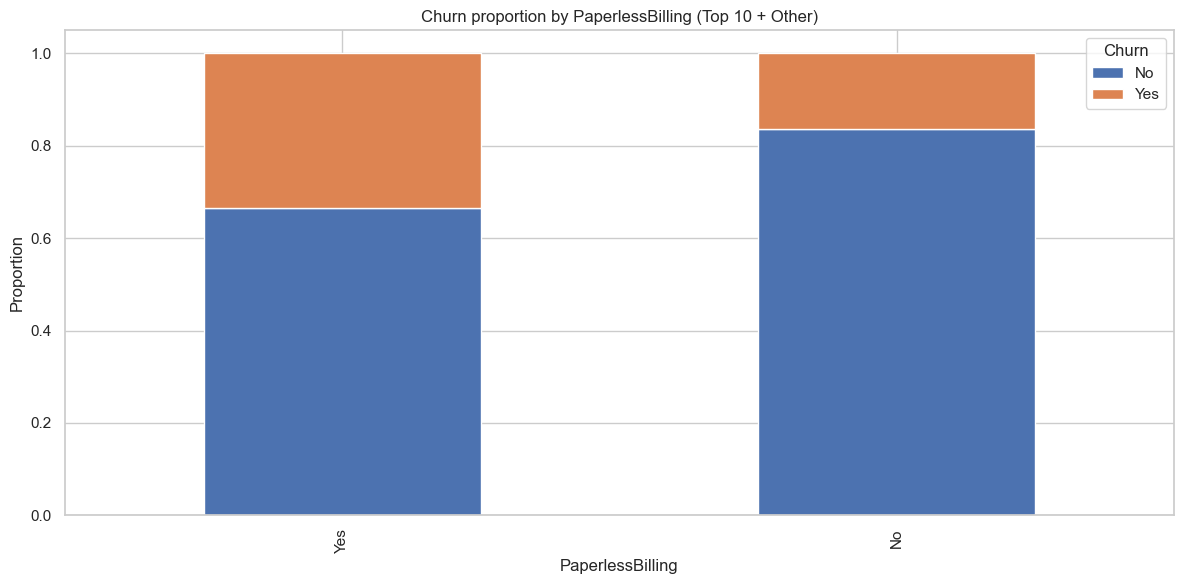

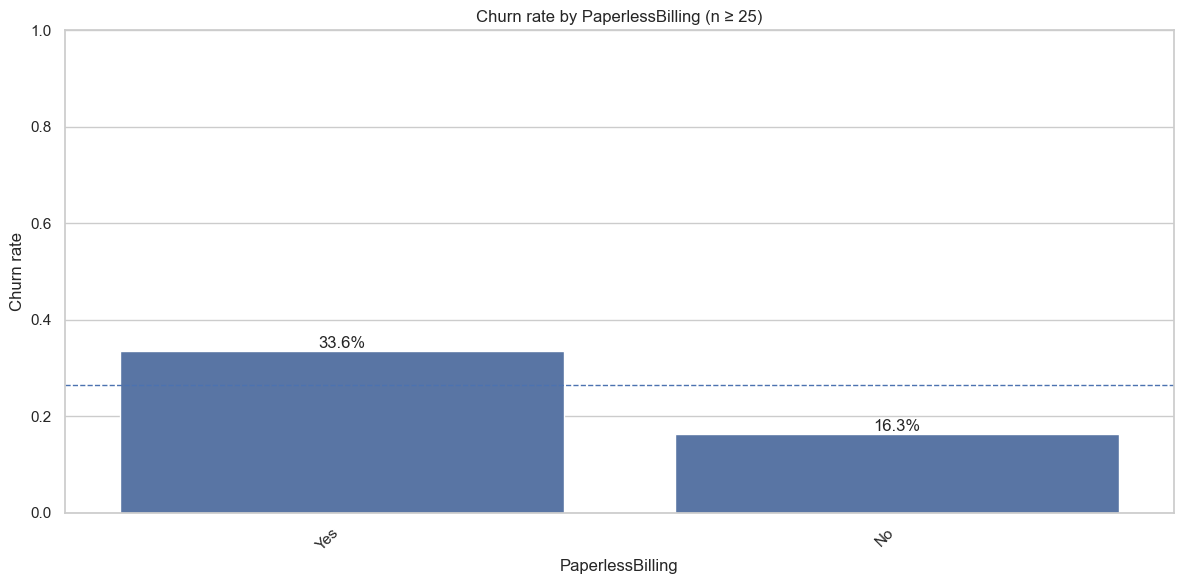


Churn rate by 'Partner':


,n,churn_rate,churned
Partner,,,
No,3641,0.330,1200
Yes,3402,0.197,669


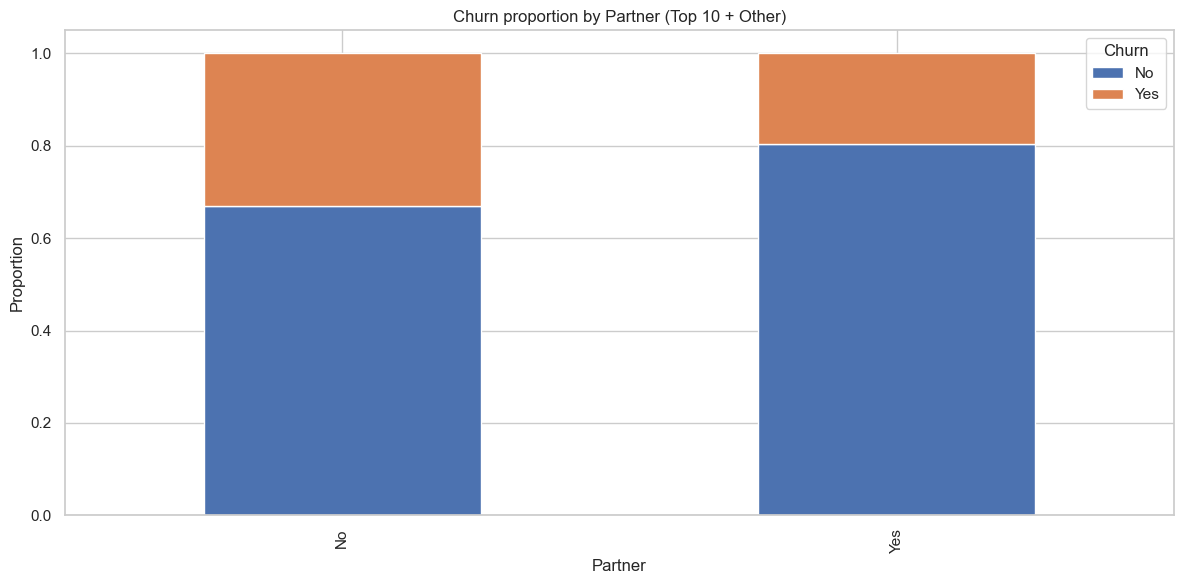

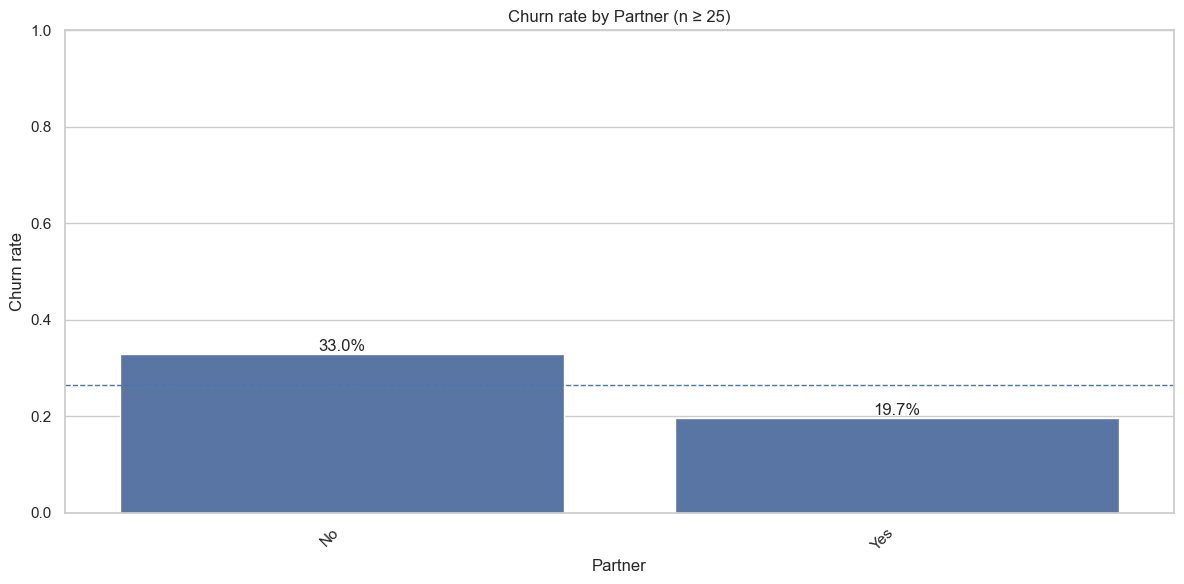


Churn rate by 'PaymentMethod':


,n,churn_rate,churned
PaymentMethod,,,
Electronic check,2365,0.453,1071
Mailed check,1612,0.191,308
Bank transfer (automatic),1544,0.167,258
Credit card (automatic),1522,0.152,232


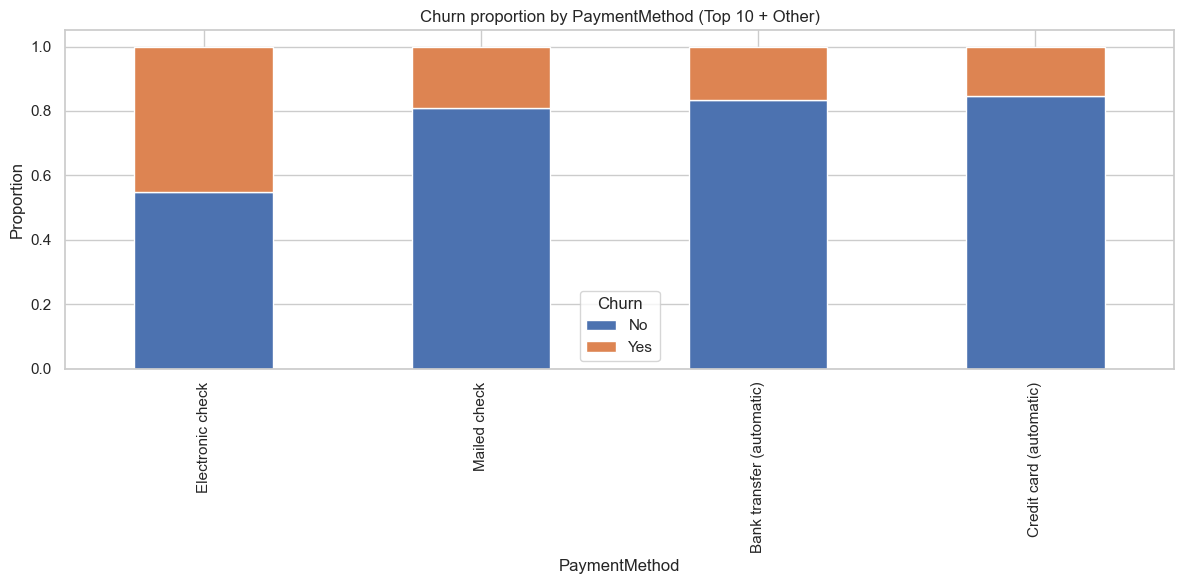

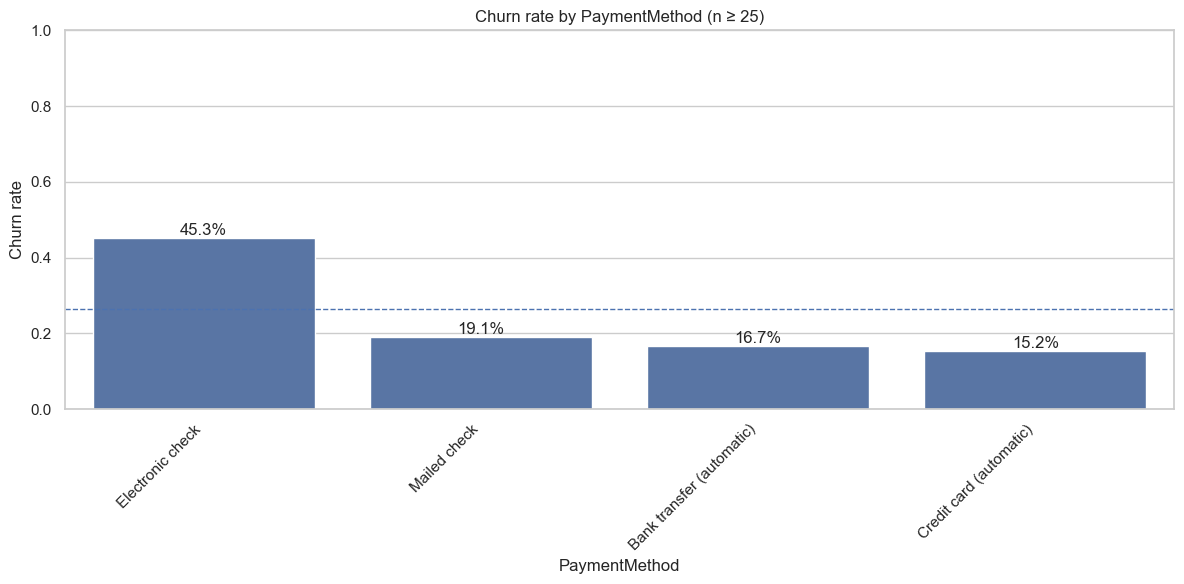


Churn rate by 'PhoneService':


,n,churn_rate,churned
PhoneService,,,
Yes,6361,0.267,1699
No,682,0.249,170


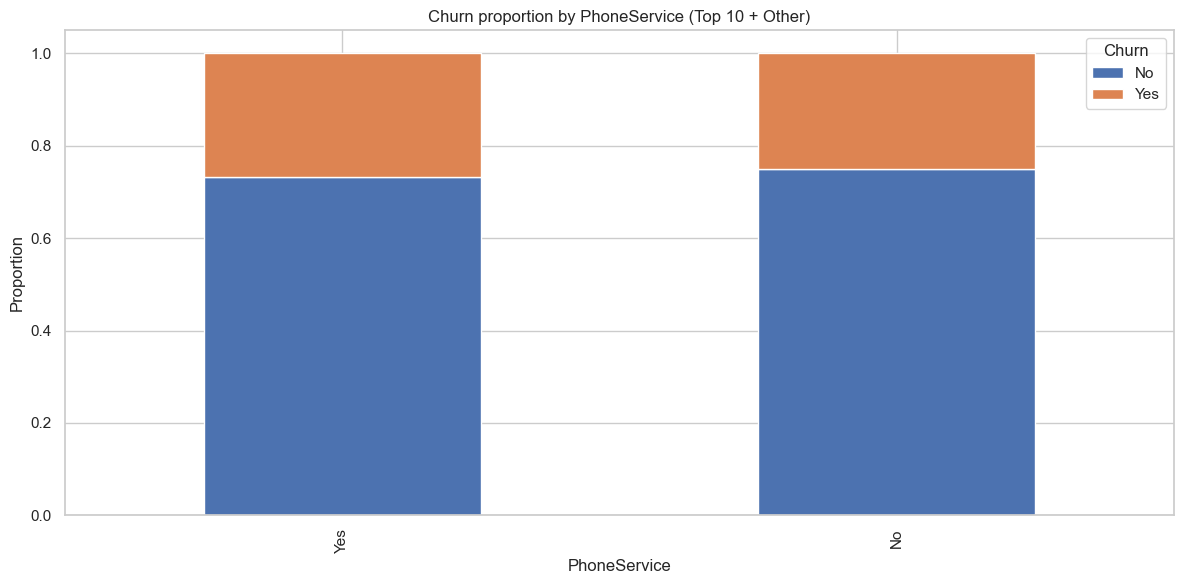

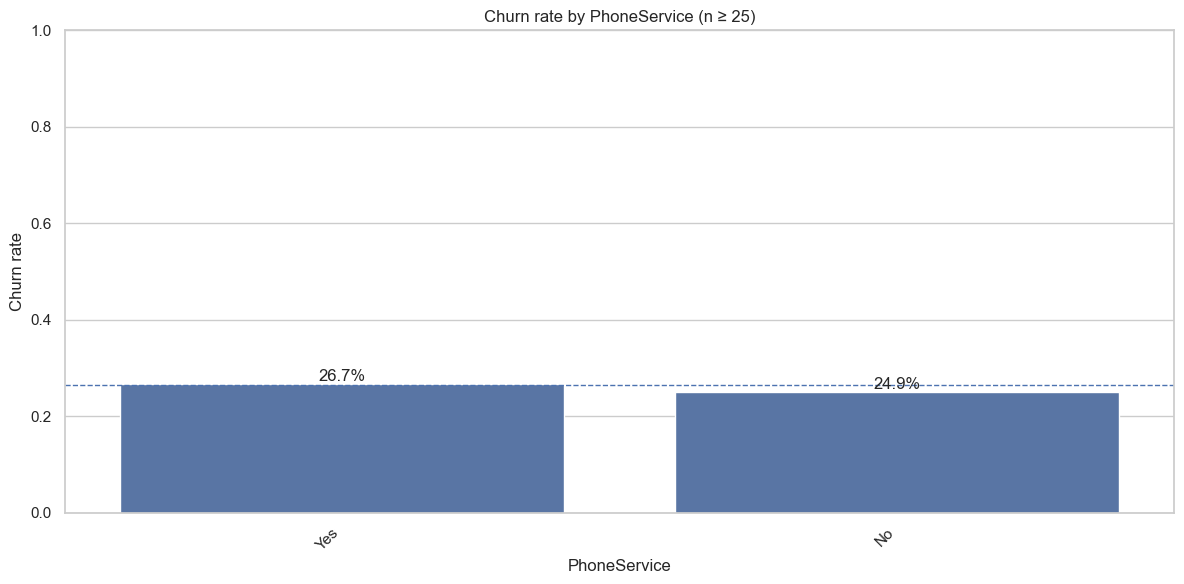


Churn rate by 'SeniorCitizen':


,n,churn_rate,churned
SeniorCitizen,,,
1,1142,0.417,476
0,5901,0.236,1393


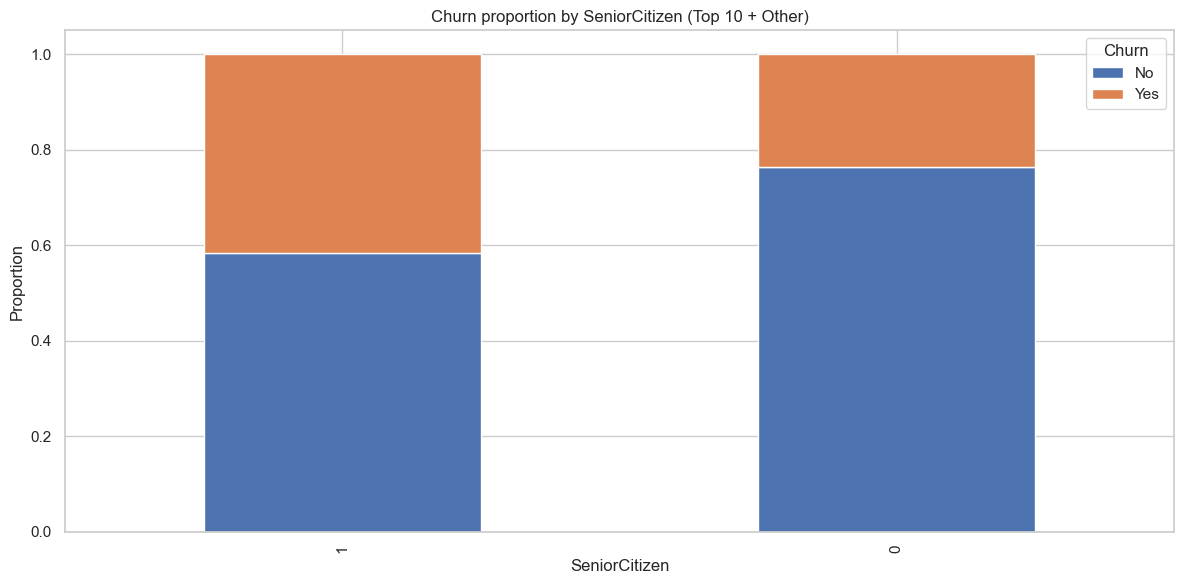

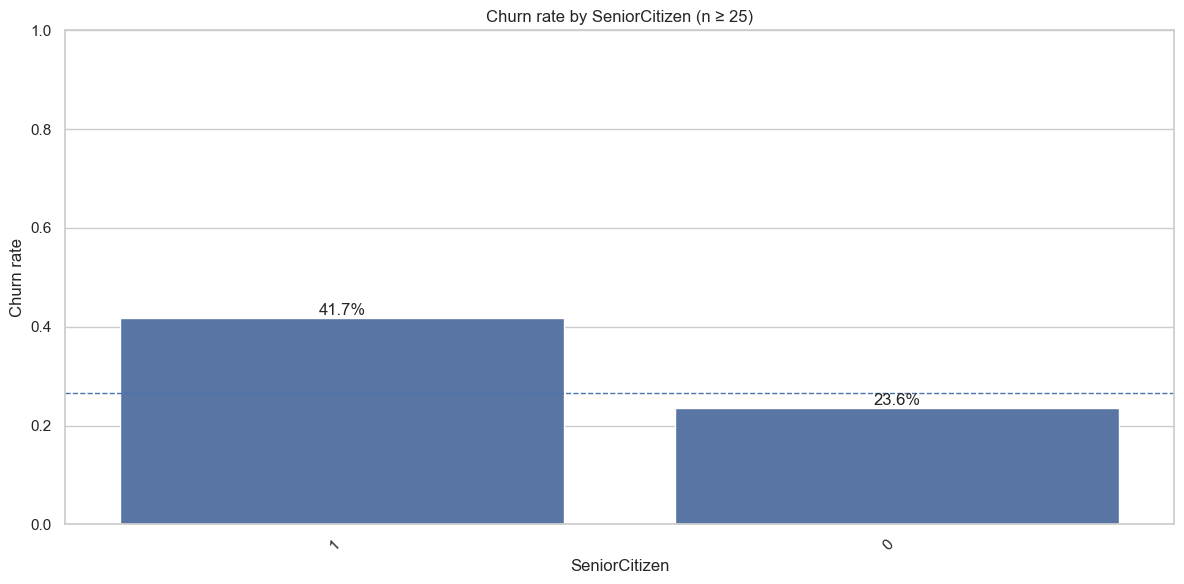


Churn rate by 'StreamingMovies':


,n,churn_rate,churned
StreamingMovies,,,
No,2785,0.337,938
Yes,2732,0.299,818
No internet service,1526,0.074,113


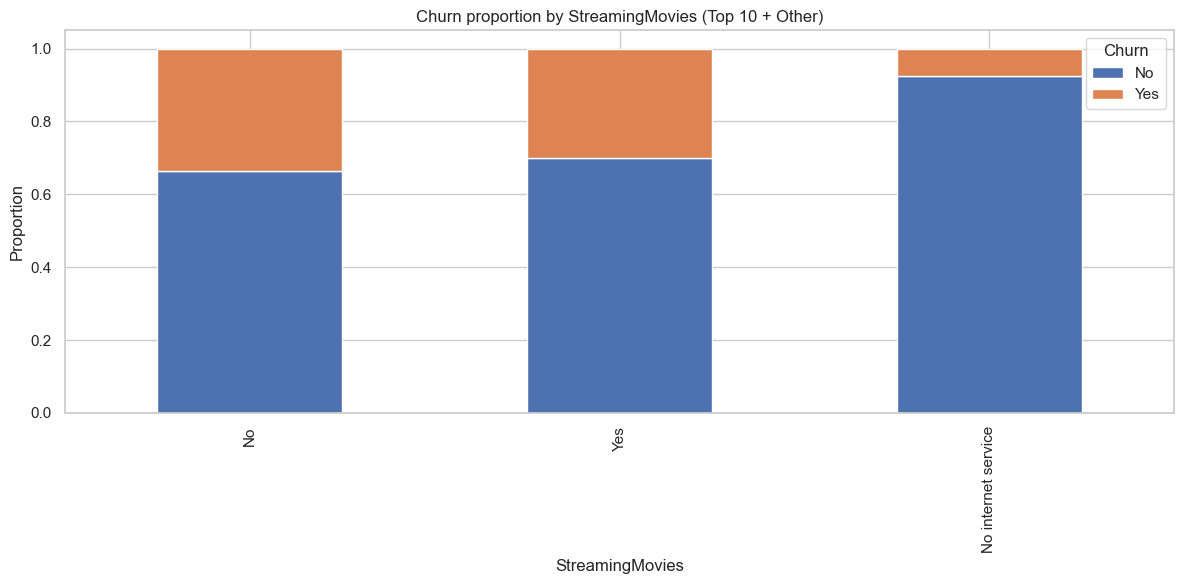

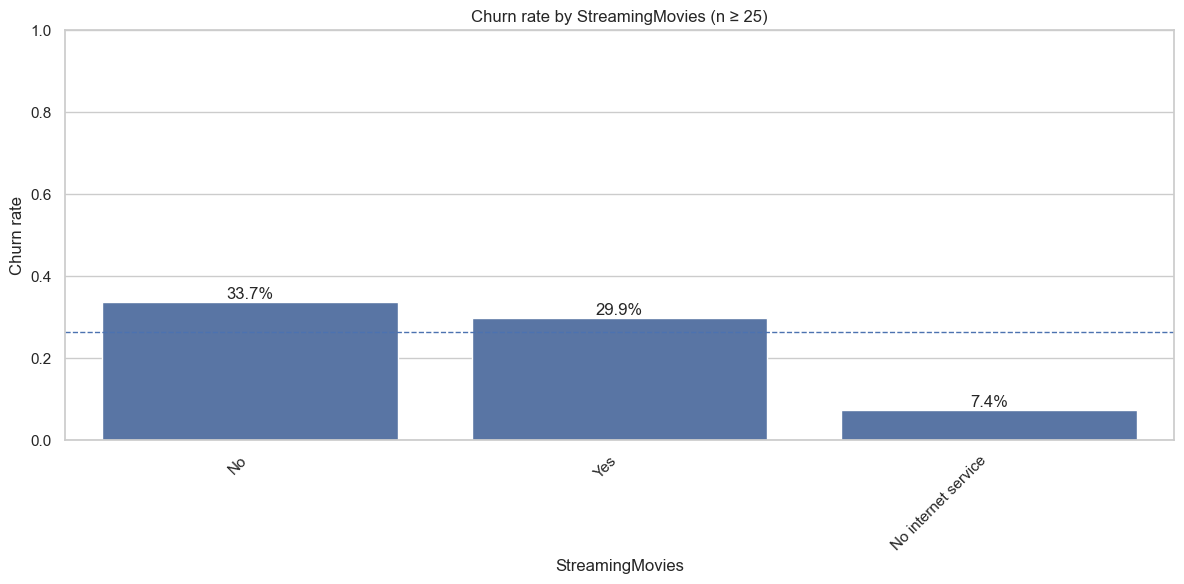


Churn rate by 'StreamingTV':


,n,churn_rate,churned
StreamingTV,,,
No,2810,0.335,942
Yes,2707,0.301,814
No internet service,1526,0.074,113


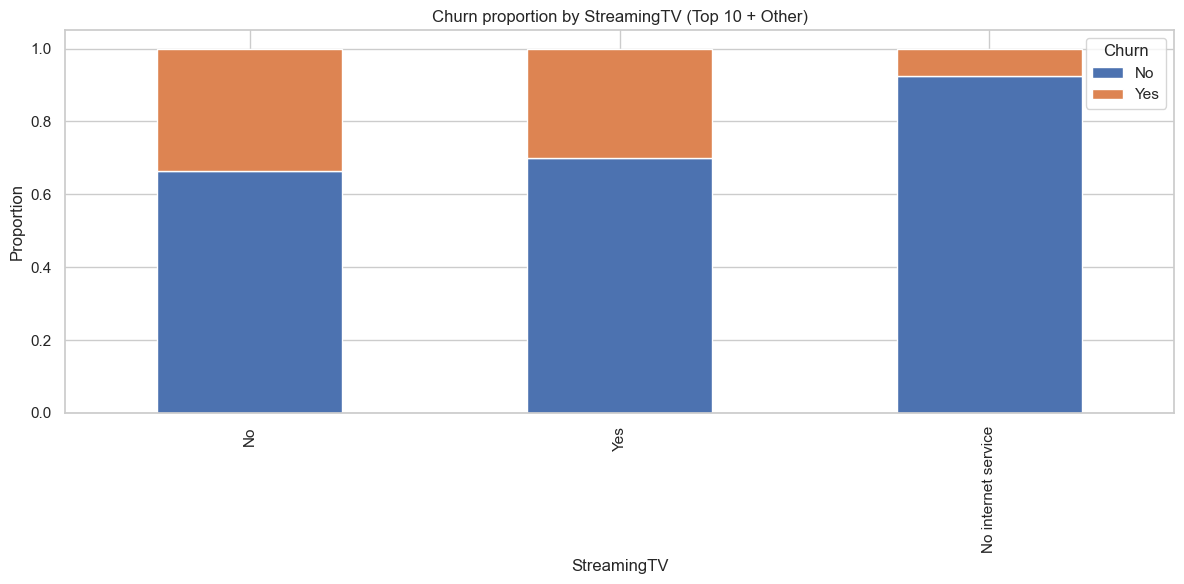

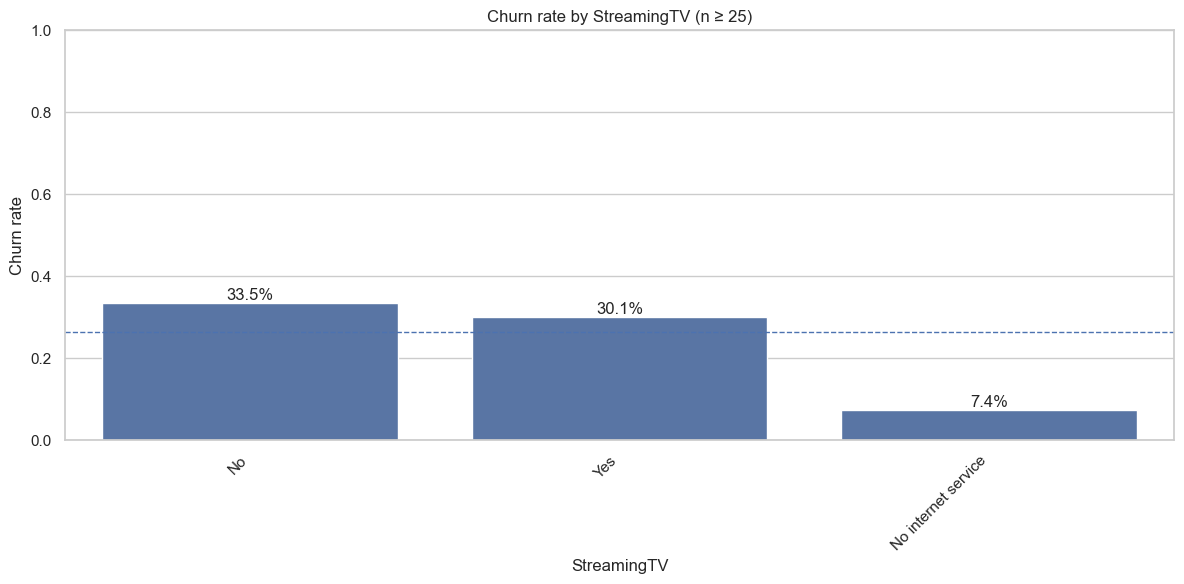


Churn rate by 'TechSupport':


,n,churn_rate,churned
TechSupport,,,
No,3473,0.416,1446
Yes,2044,0.152,310
No internet service,1526,0.074,113


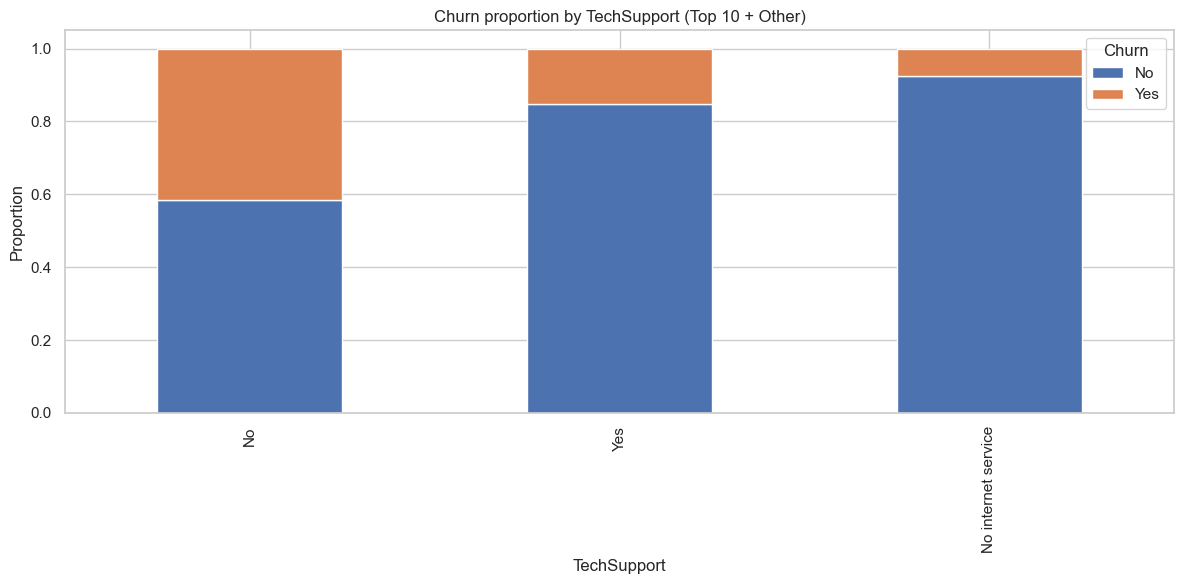

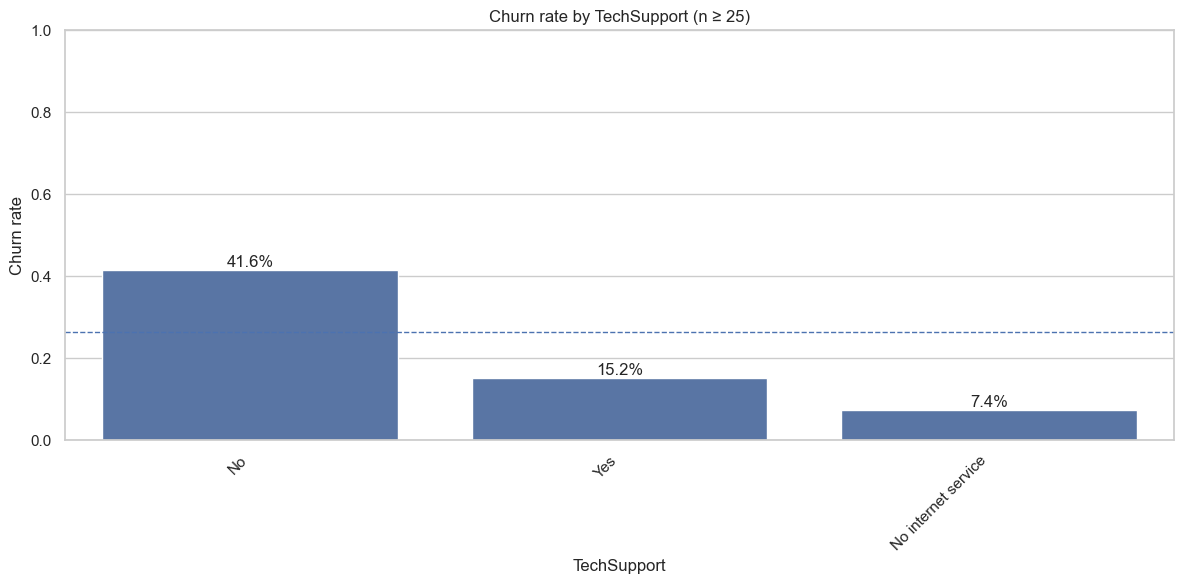


Churn rate by 'gender':


,n,churn_rate,churned
gender,,,
Female,3488,0.269,939
Male,3555,0.262,930


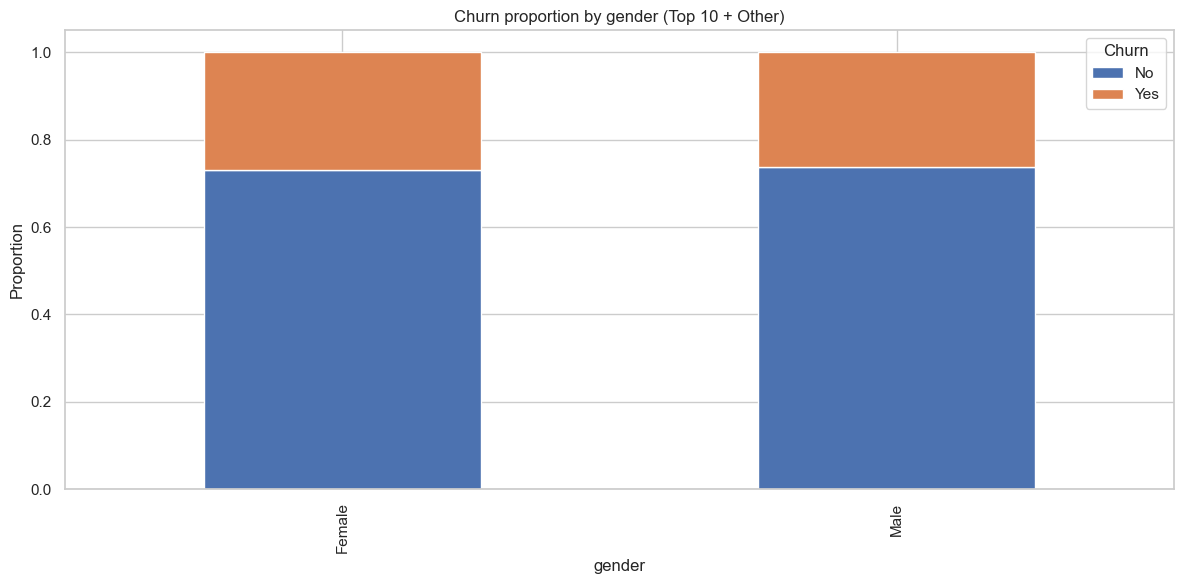

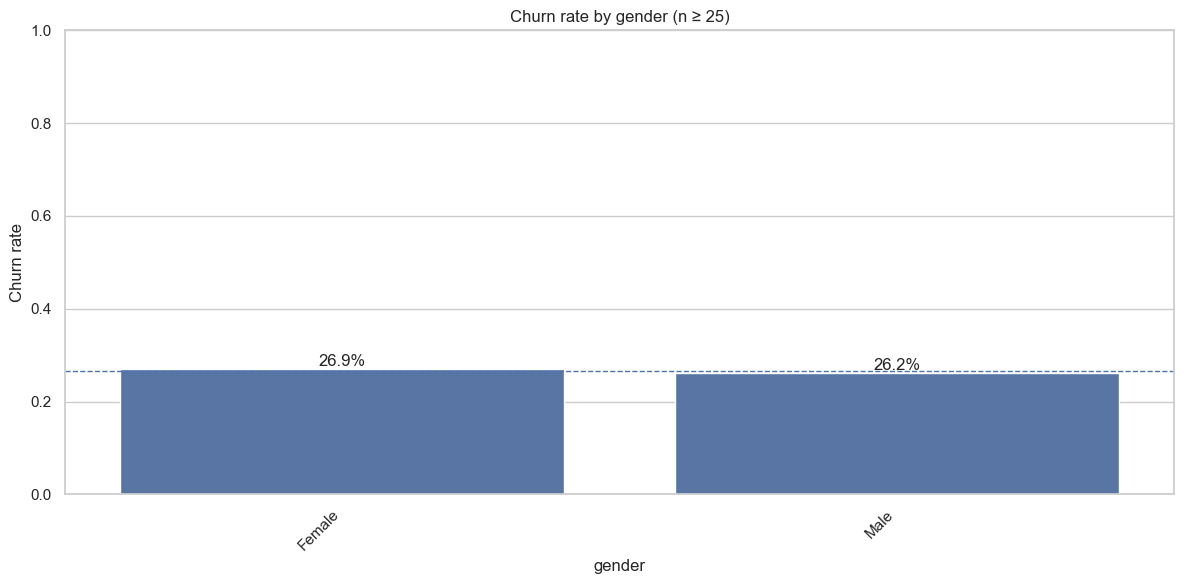

In [ ]:
# =================================================================
# 5) Feature vs Target: Univariate EDA 
#    df is not modified here.
#    For plots, keeping the top categories and group the rest into "Other".  
# =================================================================

# Columns used for numeric and categorical EDA
numeric_eda_cols = [
    c for c in numerical_cols
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
]

categorical_eda_cols = [
    c for c in categorical_cols
    if c in df.columns and c != target_col
]

# Explicitly report "numeric-in-meaning but not numeric dtype yet" (e.g., TotalCharges)
skipped_numeric_meaning = [
    c for c in numerical_cols
    if c in df.columns and not pd.api.types.is_numeric_dtype(df[c])
]
if skipped_numeric_meaning:
    print("Skipping numeric-in-meaning columns that are not numeric dtype yet (handled in cleaning later):")
    print("  " + ", ".join(skipped_numeric_meaning))

# Encode churn as 0/1 so we can compute churn rates
y = df[target_col].map({'No': 0, 'Yes': 1})

if y.isna().any():
    bad_values = df.loc[y.isna(), target_col].dropna().unique().tolist()
    vc = df[target_col].value_counts(dropna=False)
    raise ValueError(
        f"Unexpected values in '{target_col}'. Expected only 'Yes'/'No'. "
        f"Found non-mappable values: {bad_values}. "
        f"Value counts including NaN: {vc}"
    )

baseline_churn_rate = y.mean()
print(f"Baseline churn rate (Yes): {baseline_churn_rate:.2%}")

# Numeric features vs churn
print("\nNumerical features vs Churn (group summaries):")

if not numeric_eda_cols:
    print("No numerical columns available for EDA (strict numeric dtype).")
else:
    # Summary stats by churn group
    numeric_summary = (
        df.assign(_churn=y)
          .groupby('_churn', dropna=False)[numeric_eda_cols]
          .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    )
    display(numeric_summary)

    for col in numeric_eda_cols:
        fig, ax = plt.subplots()
        sns.histplot(
            data=df,
            x=col,
            hue=target_col,
            stat='density',
            common_norm=False,
            bins=30,
            ax=ax
        )
        ax.set_title(f"{col} distribution by {target_col}")
        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots()
        sns.boxplot(
            data=df,
            x=target_col,
            y=col,
            ax=ax
        )
        ax.set_title(f"{col} by {target_col}")
        ax.set_xlabel(target_col)
        ax.set_ylabel(col)
        plt.tight_layout()
        plt.show()


# Categorical/Binary features vs Churn
top_k = 10      # keep plots readable
min_count = 25  # ignore tiny groups

if not categorical_eda_cols: 
    print("No categorical columns available for EDA")
else:
    for col in categorical_eda_cols:

        print(f"\nChurn rate by '{col}':")

        # Compute churn rate table
        rate_table = (
            df.assign(_churn=y)
            .groupby(col, dropna=False)['_churn']
            .agg(n='size', churn_rate='mean', churned='sum')
            .sort_values(['churn_rate', 'n'], ascending=[False, False])
        )

        display(rate_table.head(15))

        # Work on a small copy and group rare categories into "Other"
        plot_df = df[[col, target_col]].copy()

        top_categories = (
            plot_df[col]
            .value_counts(dropna=False)
            .head(top_k)
            .index
        )

        plot_df[col] = plot_df[col].where(
            plot_df[col].isin(top_categories),
            other='Other'
        )

        # Stacked proportion plot
        ct = pd.crosstab(
            plot_df[col],
            plot_df[target_col],
            normalize='index',
            dropna=False
        )

        sort_col = 'Yes' if 'Yes' in ct.columns else ct.columns[-1]
        ct = ct.sort_values(by=sort_col, ascending=False)

        fig, ax = plt.subplots()
        ct.plot(kind='bar', stacked=True, ax=ax)
        ax.set_title(f"{target_col} proportion by {col} (Top {top_k} + Other)")
        ax.set_xlabel(col)
        ax.set_ylabel('Proportion')
        plt.tight_layout()
        plt.show()

        # Churn rate barplot (filter tiny categories)
        support = plot_df[col].value_counts(dropna=False)
        rate_tbl = (
            plot_df.assign(_churn=y)
                .groupby(col, dropna=False)['_churn']
                .mean()
                .sort_values(ascending=False)
        )

        rate_tbl = rate_tbl[support >= min_count].head(top_k)

        if rate_tbl.empty:
            print(f"Skipping churn-rate plot for '{col}' (no categories with n ≥ {min_count}).")
        else:
            fig, ax = plt.subplots()
            sns.barplot(x=rate_tbl.index.astype(str), y=rate_tbl.values, ax=ax)
            ax.set_title(f"Churn rate by {col} (n ≥ {min_count})")
            ax.set_xlabel(col)
            ax.set_ylabel('Churn rate')
            ax.set_ylim(0, 1)
            ax.axhline(baseline_churn_rate, linestyle="--", linewidth=1)

            for i, v in enumerate(rate_tbl.values):
                ax.text(i, v, f"{v:.1%}", ha='center', va='bottom')

            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

In [ ]:
# =======================================================================================
# 6) Data Cleaning - Minimal fixes to make df model ready while keeping raw_df unchanged
#    Change TotalCharges into numeric / Fill TotalCharges = 0 when tenure = 0
# =======================================================================================

# Identifier check
if df[id_col].isna().any():
    raise ValueError(f"Identifier column '{id_col}' contains missing values (unexpected).")

dup_mask = df[id_col].duplicated(keep=False)
if dup_mask.any():
    dup_n = int(dup_mask.sum())
    examples = df.loc[dup_mask, id_col].astype(str).head(5).tolist()
    raise ValueError(
        f"Identifier column '{id_col}' has {dup_n} duplicated rows (unexpected). "
        f"Example duplicated IDs: {examples}"
    )

# Work on a copy: raw df remains intact for earlier EDA
df_clean = df.copy()

# Convert TotalCharges to numeric and diagnose any potential unexpected values
total_charges_col = 'TotalCharges'
n_filled_totalcharges = 0  # tracked for summary

if total_charges_col in df_clean.columns:
    tc = df_clean[total_charges_col]
    print(f"TotalCharges dtype before: {tc.dtype}")

    if not pd.api.types.is_numeric_dtype(tc):
        tc_str = tc.astype('string').str.strip()
    
        # Count blank/whitespace-only entries
        n_blank = int((tc_str == '').sum())
        print(f"TotalCharges blank/whitespace-only entries (after strip): {n_blank:,}")

        # Treat blanks as missing
        tc_fixed = tc_str.replace({"": pd.NA})

        # Validate: all remaining non-missing values must be numeric
        candidate = tc_fixed.dropna()
        coerced = pd.to_numeric(candidate, errors='coerce')
        bad_mask = coerced.isna()

        if bad_mask.any():
            bad_tokens = candidate[bad_mask].value_counts().head(10)
            bad_example_idx = candidate[bad_mask].index[:8]
            bad_examples = df_clean.loc[bad_example_idx, [id_col, 'tenure', total_charges_col]]

            raise ValueError(
                "Unexpected non-numeric tokens detected in TotalCharges.\n"
                f"Top tokens:\n{bad_tokens.to_string()}\n\n"
                f"Example rows:\n{bad_examples.to_string(index=False)}"
            )

        # Safe conversion (now guaranteed clean)
        df_clean[total_charges_col] = pd.to_numeric(tc_fixed, errors='raise')

    if not pd.api.types.is_numeric_dtype(df_clean[total_charges_col]):
        raise TypeError("TotalCharges is not numeric dtype after conversion.")

    print(f"TotalCharges dtype after: {df_clean[total_charges_col].dtype}")
    print(f"TotalCharges missing after conversion: {df_clean[total_charges_col].isna().sum():,}")

# Fill TotalCharges with 0 for customers with tenure == 0 (validate first)
if {'tenure', total_charges_col}.issubset(df_clean.columns):
    tc_na_mask = df_clean[total_charges_col].isna()
    n_tc_na = int(tc_na_mask.sum())

    if n_tc_na > 0:
        tenure_when_missing = df_clean.loc[tc_na_mask, 'tenure']
        nonzero_tenure = tenure_when_missing[tenure_when_missing != 0]

        if not nonzero_tenure.empty:
            examples = df_clean.loc[nonzero_tenure.index, [id_col, "tenure", total_charges_col]].head(8)
            raise ValueError(
                "TotalCharges is missing for some rows where tenure != 0. "
                "Refusing to fill because 'TotalCharges=0 when tenure==0' rule is violated. "
                f"Examples: {examples}"
            )

        df_clean.loc[tc_na_mask, total_charges_col] = 0.0
        n_filled_totalcharges = n_tc_na
        print(f"\nFilled TotalCharges=0.0 for {n_filled_totalcharges:,} rows (validated tenure==0 rule).")

# Final checks and summary
if total_charges_col in df_clean.columns:
    if (df_clean[total_charges_col] < 0).any():
        n_neg = int((df_clean[total_charges_col] < 0).sum())
        raise ValueError(f"TotalCharges contains {n_neg:,} negative values (unexpected).")

    n_tc_na_after = int(df_clean[total_charges_col].isna().sum())
    if n_tc_na_after > 0:
        print(
            f"\nWarning: TotalCharges still has {n_tc_na_after:,} missing values after deterministic fills. "
            "Remaining missingness will be handled during preprocessing "
        )

# Final missingness snapshot (post-deterministic cleaning)
missing_counts_final = df_clean.isna().sum().sort_values(ascending=False)
missing_counts_final = missing_counts_final[missing_counts_final > 0]

if missing_counts_final.empty:
    print("\nNo remaining missing values after deterministic cleaning.")
else:
    final_missing_report = pd.DataFrame({
        'n_missing': missing_counts_final,
        'pct_missing': (missing_counts_final / len(df_clean) * 100).round(3),
    })
    print("\nRemaining missing values after deterministic cleaning (to be handled in pipeline):")
    display(final_missing_report)

print("\nCleaning summary:")
if total_charges_col in df_clean.columns:
    print(f"TotalCharges dtype: {df_clean[total_charges_col].dtype}")
    print(f"TotalCharges fills applied (tenure==0): {n_filled_totalcharges:,}")
print("  - Raw df preserved, using df_clean for modeling.")


TotalCharges dtype before: object
TotalCharges blank/whitespace-only entries (after strip): 11
TotalCharges dtype after: Float64
TotalCharges missing after conversion: 11

Filled TotalCharges=0.0 for 11 rows (validated tenure==0 rule).

No remaining missing values after deterministic cleaning.

Cleaning summary:
TotalCharges dtype: Float64
TotalCharges fills applied (tenure==0): 11
  - Raw df preserved, using df_clean for modeling.


In [9]:
# ====================================
# 6.5) Feature Grouping after cleaning
# ====================================

# Rebuild groups from df_clean
feature_cols_clean = [c for c in df_clean.columns if c not in {id_col, target_col}]

numeric_by_dtype_clean = df_clean[feature_cols_clean].select_dtypes(include=["number"]).columns.tolist()
categorical_by_dtype_clean = df_clean[feature_cols_clean].select_dtypes(exclude=["number"]).columns.tolist()

# True-Meaning overrides 
likely_categorical_meaning = ["SeniorCitizen"]  # numeric 0/1 but categorical meaning
likely_categorical_meaning = [c for c in likely_categorical_meaning if c in df_clean.columns]

numerical_cols_clean = sorted((set(numeric_by_dtype_clean) - set(likely_categorical_meaning)))
categorical_cols_clean = sorted((set(categorical_by_dtype_clean) | set(likely_categorical_meaning)))

# Mutually exclusive groups (important for ColumnTransformer since it expects a clean split)
overlap = set(numerical_cols_clean) & set(categorical_cols_clean)
if overlap:
    raise ValueError(f"Numerical/Categorical overlap after cleaning: {sorted(overlap)}")

print("\nPost-cleaning feature groups:")
print(f"Numerical ({len(numerical_cols_clean)}): {numerical_cols_clean}")
print(f"Categorical ({len(categorical_cols_clean)}): {categorical_cols_clean}")



Post-cleaning feature groups:
Numerical (3): ['MonthlyCharges', 'TotalCharges', 'tenure']
Categorical (16): ['Contract', 'Dependents', 'DeviceProtection', 'InternetService', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'PaperlessBilling', 'Partner', 'PaymentMethod', 'PhoneService', 'SeniorCitizen', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'gender']
